In [12]:
import pandas as pd
import os

file_path = os.path.join('..', 'data', 'Dataset_Listo_Para_ML.xlsx')
df = pd.read_excel(file_path, engine='openpyxl')

# Verificación de valores nulos
print(df.isnull().sum())

# Análisis de valores únicos para variables categóricas
for col in ['SECTOR', 'SEXO', 'OCUPACION', 'TIPO_ACCIDENTE']:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())

AÑO               0
REGION            0
SECTOR            0
SEXO              0
OCUPACION         0
TIPO_ACCIDENTE    0
SEVERIDAD         0
dtype: int64

--- SECTOR ---
SECTOR
INDUSTRIAS MANUFACTURERAS            2638
INMOBILIARIA Y ALQUILERES            2291
COMERCIO Y REPARACIÓN AUTOMOTRIZ     1396
CONSTRUCCIÓN                         1147
MINERÍA Y CANTERAS                   1042
TRANSPORTE Y LOGÍSTICA                961
SERVICIOS SOCIALES Y DE SALUD         622
HOTELES Y RESTAURANTES                616
SERVICIOS COMUNITARIOS Y SOCIALES     444
ADMINISTRACIÓN PÚBLICA                274
PESCA                                 243
AGRICULTURA Y GANADERÍA               109
SUMIN.,ELECTRICIDAD, GAS Y AGUA        99
EDUCACIÓN                              96
INTERMEDIACIÎ FINANCIERA               22
Name: count, dtype: int64

--- SEXO ---
SEXO
MASCULINO    10186
FEMENINO      1814
Name: count, dtype: int64

--- OCUPACION ---
OCUPACION
OPERARIO                    5055
EMPLEADO               

In [13]:
# Corrección 1: carácter corrupto
df['SECTOR'] = df['SECTOR'].str.strip().str.upper()
df['SECTOR'] = df['SECTOR'].replace(
    'INTERMEDIACIÎ FINANCIERA', 
    'INTERMEDIACIÓN FINANCIERA'
)

# Corrección 2: unificar el duplicado semántico
df['TIPO_ACCIDENTE'] = df['TIPO_ACCIDENTE'].replace(
    'CHOQUE O GOLPE POR OBJETO',
    'GOLPE O CHOQUE CON OBJETO'
)

# Verificar que quedó bien
print(df['SECTOR'].value_counts())
print(df['TIPO_ACCIDENTE'].value_counts())

SECTOR
INDUSTRIAS MANUFACTURERAS            2638
INMOBILIARIA Y ALQUILERES            2291
COMERCIO Y REPARACIÓN AUTOMOTRIZ     1396
CONSTRUCCIÓN                         1147
MINERÍA Y CANTERAS                   1042
TRANSPORTE Y LOGÍSTICA                961
SERVICIOS SOCIALES Y DE SALUD         622
HOTELES Y RESTAURANTES                616
SERVICIOS COMUNITARIOS Y SOCIALES     444
ADMINISTRACIÓN PÚBLICA                274
PESCA                                 243
AGRICULTURA Y GANADERÍA               109
SUMIN.,ELECTRICIDAD, GAS Y AGUA        99
EDUCACIÓN                              96
INTERMEDIACIÓN FINANCIERA              22
Name: count, dtype: int64
TIPO_ACCIDENTE
CAÍDA AL MISMO NIVEL                                   3231
CAÍDA DE OBJETOS                                       2192
ATRAPAMIENTO POR MÁQUINA                               1660
SOBREESFUERZO ERGONÓMICO                               1360
GOLPE O CHOQUE CON OBJETO                              1194
CORTE CON OBJETO PUNZO

In [14]:
from sklearn.preprocessing import LabelEncoder

features = ['SECTOR', 'SEXO', 'OCUPACION', 'TIPO_ACCIDENTE']
X = df[features].copy()

encoders = {}
for col in features:
    le = LabelEncoder()
    X[col] = le.fit_transform(df[col])
    encoders[col] = le  # guardas el encoder para interpretar resultados después
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

y = df['SEVERIDAD']

SECTOR: {'ADMINISTRACIÓN PÚBLICA': 0, 'AGRICULTURA Y GANADERÍA': 1, 'COMERCIO Y REPARACIÓN AUTOMOTRIZ': 2, 'CONSTRUCCIÓN': 3, 'EDUCACIÓN': 4, 'HOTELES Y RESTAURANTES': 5, 'INDUSTRIAS MANUFACTURERAS': 6, 'INMOBILIARIA Y ALQUILERES': 7, 'INTERMEDIACIÓN FINANCIERA': 8, 'MINERÍA Y CANTERAS': 9, 'PESCA': 10, 'SERVICIOS COMUNITARIOS Y SOCIALES': 11, 'SERVICIOS SOCIALES Y DE SALUD': 12, 'SUMIN.,ELECTRICIDAD, GAS Y AGUA': 13, 'TRANSPORTE Y LOGÍSTICA': 14}
SEXO: {'FEMENINO': 0, 'MASCULINO': 1}
OCUPACION: {'CAPATAZ': 0, 'EMPLEADO': 1, 'FUNCIONARIO': 2, 'JEFE DE PLANTA': 3, 'OFICIAL': 4, 'OPERARIO': 5, 'PEÓN': 6, 'TRABAJADOR INDEPENDIENTE': 7, 'TÉCNICO': 8}
TIPO_ACCIDENTE: {'ATRAPAMIENTO POR MÁQUINA': 0, 'CAÍDA AL MISMO NIVEL': 1, 'CAÍDA DE OBJETOS': 2, 'CONTACTO CON SUSTANCIA QUÍMICA': 3, 'CONTACTO ELÉCTRICO': 4, 'CORTE CON OBJETO PUNZOCORTANTE': 5, 'ELECTROCUCIÓN': 6, 'EXPOSICIÓN A, O CONTACTO CON, TEMPERATURAS EXTREMAS': 7, 'GOLPE O CHOQUE CON OBJETO': 8, 'SOBREESFUERZO ERGONÓMICO': 9}


In [25]:
# Visualización del desbalanceo de la variable objetivo
print(y.value_counts())
print(y.value_counts(normalize=True).mul(100).round(1))

SEVERIDAD
2    5338
1    4000
3    2662
Name: count, dtype: int64
SEVERIDAD
2    44.5
1    33.3
3    22.2
Name: proportion, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y   
)

print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

Train: 9600 | Test: 2400


In [ ]:
from sklearn.ensemble import RandomForestClassifier

modelo = RandomForestClassifier(
    n_estimators=100,     
    max_depth=None,       
    class_weight='balanced',
    random_state=42
)

modelo.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [26]:
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, f1_score)

y_pred = modelo.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print()
print(classification_report(y_test, y_pred,
      target_names=['Leve (1)', 'Grave (2)', 'Mortal (3)']))
print()
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7446

              precision    recall  f1-score   support

    Leve (1)       0.68      0.66      0.67       800
   Grave (2)       0.76      0.69      0.72      1068
  Mortal (3)       0.81      0.97      0.88       532

    accuracy                           0.74      2400
   macro avg       0.75      0.78      0.76      2400
weighted avg       0.74      0.74      0.74      2400


Matriz de confusión:
[[529 224  47]
 [251 742  75]
 [  0  16 516]]


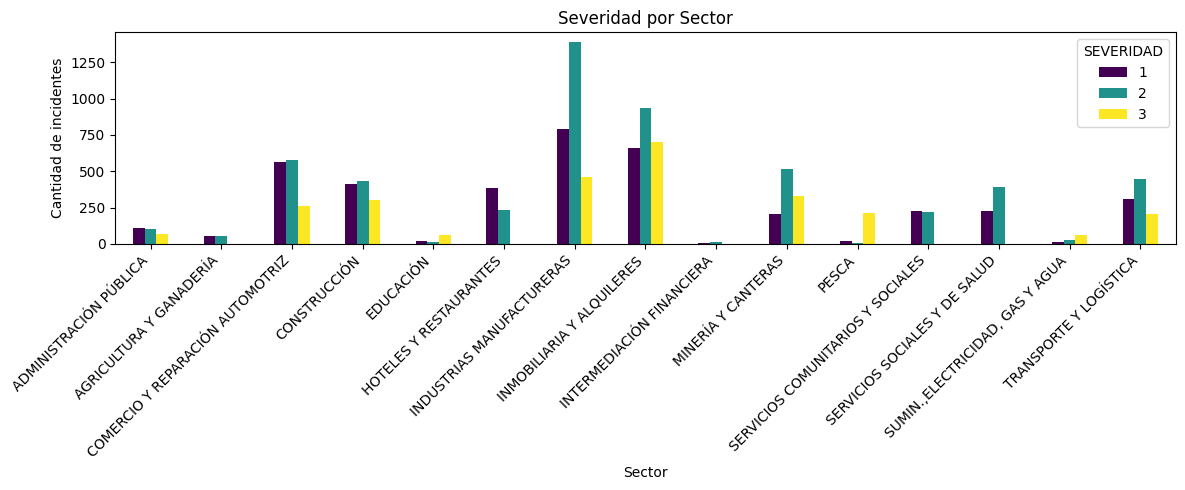

In [19]:
import matplotlib.pyplot as plt

# Distribución de severidad por sector
tabla = pd.crosstab(df['SECTOR'], df['SEVERIDAD'])
tabla.plot(kind='bar', figsize=(12, 5), colormap='viridis')
plt.title('Severidad por Sector')
plt.xlabel('Sector')
plt.ylabel('Cantidad de incidentes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('eda_severidad_sector.png', dpi=150)
plt.show()

In [20]:
importancias = pd.Series(
    modelo.feature_importances_,
    index=features
).sort_values(ascending=False)

print(importancias)

TIPO_ACCIDENTE    0.554021
SECTOR            0.213323
OCUPACION         0.170920
SEXO              0.061736
dtype: float64


In [21]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(modelo, X, y, cv=5, scoring='accuracy')

print("Scores por fold:", cv_scores.round(4))
print(f"Media:          {cv_scores.mean():.4f}")
print(f"Desviación std: {cv_scores.std():.4f}")

Scores por fold: [0.7279 0.7254 0.74   0.7317 0.7417]
Media:          0.7333
Desviación std: 0.0065


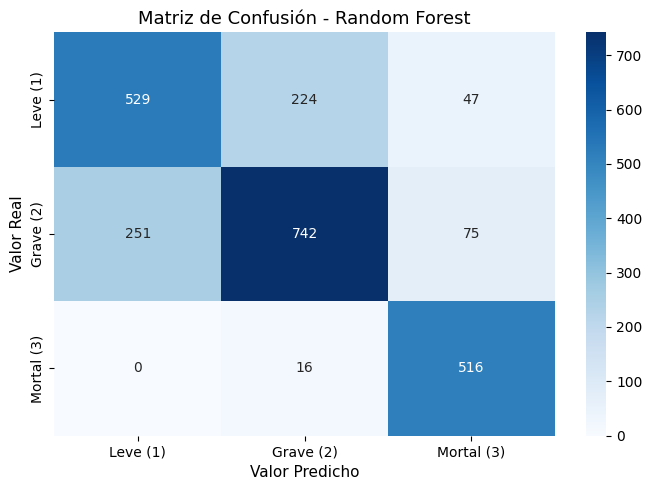

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Leve (1)', 'Grave (2)', 'Mortal (3)'],
            yticklabels=['Leve (1)', 'Grave (2)', 'Mortal (3)'])
plt.title('Matriz de Confusión - Random Forest', fontsize=13)
plt.ylabel('Valor Real', fontsize=11)
plt.xlabel('Valor Predicho', fontsize=11)
plt.tight_layout()
plt.savefig('mc_random_forest.png', dpi=300, bbox_inches='tight')
plt.show()

In [23]:
import joblib

# Exportando la variable 'modelo'
joblib.dump(modelo, '../models/rf_model.pkl')

['../models/rf_model.pkl']

In [24]:
import joblib
joblib.dump(encoders, '../models/encoders.pkl')
print("✅ Encoders guardado")

✅ Encoders guardado
